In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

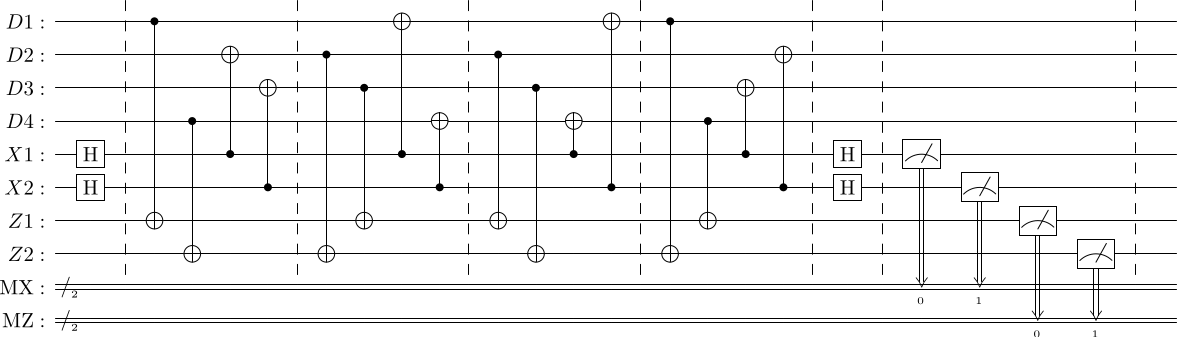

In [2]:
d1 = QuantumRegister(1, 'D1')
d2 = QuantumRegister(1, 'D2')
d3 = QuantumRegister(1, 'D3')
d4 = QuantumRegister(1, 'D4')

x1 = QuantumRegister(1, 'X1')
x2 = QuantumRegister(1, 'X2')

z1 = QuantumRegister(1, 'Z1')
z2 = QuantumRegister(1, 'Z2')

mx = ClassicalRegister(2, 'MX')
mz = ClassicalRegister(2, 'MZ')

circuit = QuantumCircuit(d1,d2,d3,d4,x1,x2,z1,z2, mx, mz)

circuit.h(x1)
circuit.h(x2)
circuit.barrier()

circuit.cx(d1,z1)
circuit.cx(d4,z2)
circuit.cx(x1,d2)
circuit.cx(x2,d3)
circuit.barrier()

circuit.cx(d2,z2)
circuit.cx(d3,z1)
circuit.cx(x1,d1)
circuit.cx(x2,d4)
circuit.barrier()

circuit.cx(d2,z1)
circuit.cx(d3,z2)
circuit.cx(x1,d4)
circuit.cx(x2,d1)
circuit.barrier()

circuit.cx(d1,z2)
circuit.cx(d4,z1)
circuit.cx(x1,d3)
circuit.cx(x2,d2)
circuit.barrier()

circuit.h(x1)
circuit.h(x2)
circuit.barrier()

circuit.measure(x1, mx[0])
circuit.measure(x2, mx[1])
circuit.measure(z1, mz[0])
circuit.measure(z2, mz[1])
circuit.barrier()

circuit.draw(output="latex", filename="qiskit_cx.png")

In [3]:
# Get the count of each operation
op_counts = circuit.count_ops()
print("Operation Counts")

for op in op_counts.keys():
    if op != "barrier":
        print(f"{op}: {op_counts[op]}")

Operation Counts
cx: 16
h: 4
measure: 4
